In [18]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
from seed_fix import set_seeds
from functions_kde_js import ( run_md_sensitivity_analysis, run_cluster_threshold_sensitivity)
from my_imports import  plot1_params
from clustering_functions import run_dynamic_clustering
set_seeds(seed=42)
plot1_params()

In [19]:
state = run_dynamic_clustering(global_start_date="07-2018",
                               global_end_date="04-2019",
                               js_lim_month=0.26,
                               js_lim_cluster=0.36,
                               zone="America/Los_Angeles_ACN",
                               file_path="data/test_ACN_data.parquet")
cluster_objects_pool = state["cluster_objects_pool"]
monthly_kde = state["monthly_kde"]
monthly_kde_mD = state["monthly_kde_mD"]
cluster_kdes = state["cluster_kdes"]

stream_order = state["stream_order"]
kmeans_objects_dict = state["kmeans_objects_dict"]
similarity_matrix = state["similarity_matrix"]

js_per_feature_mat = state["js_per_feature_mat"]
js_mat_time_order = state["js_mat_time_order"]
js_md_per_month = state["js_md_per_month"]

all_monthly_kde = state["all_monthly_kde"]
all_clusters_kde = state["all_clusters_kde"]
scaler = state["scaler"]

current_month_pair: 07-2018 08-2018
Analyzing first month in the data.
3, Number of Optimal Clusters for Month 07-2018
current_month_pair: 08-2018 09-2018
08-2018 is similar to reference month 07-2018. JS mD = 0.13926
current_month_pair: 09-2018 10-2018
09-2018 is similar to reference month 07-2018. JS mD = 0.18458
current_month_pair: 10-2018 11-2018
10-2018 is similar to reference month 07-2018. JS mD = 0.23457
current_month_pair: 11-2018 12-2018
11-2018 is a new pattern. JS mD = 0.31533, threshold = 0.26
5, Number of Optimal Clusters for Month 11-2018
current_month_pair: 12-2018 01-2019
12-2018 is similar to reference month 11-2018. JS mD = 0.12614
current_month_pair: 01-2019 02-2019
01-2019 is similar to reference month 11-2018. JS mD = 0.15122
current_month_pair: 02-2019 03-2019
02-2019 is similar to reference month 11-2018. JS mD = 0.14751
current_month_pair: 03-2019 04-2019
03-2019 is similar to reference month 11-2018. JS mD = 0.15033


In [ ]:
results = run_md_sensitivity_analysis(
    global_start_date="07-2018",
    global_end_date="04-2019",
    plot=True,
    zone="America/Los_Angeles_ACN",
    file_path="data/test_ACN_data.parquet"
)

In [ ]:
results = run_cluster_threshold_sensitivity(
    all_clusters_kde=all_clusters_kde,
    plot=True
)

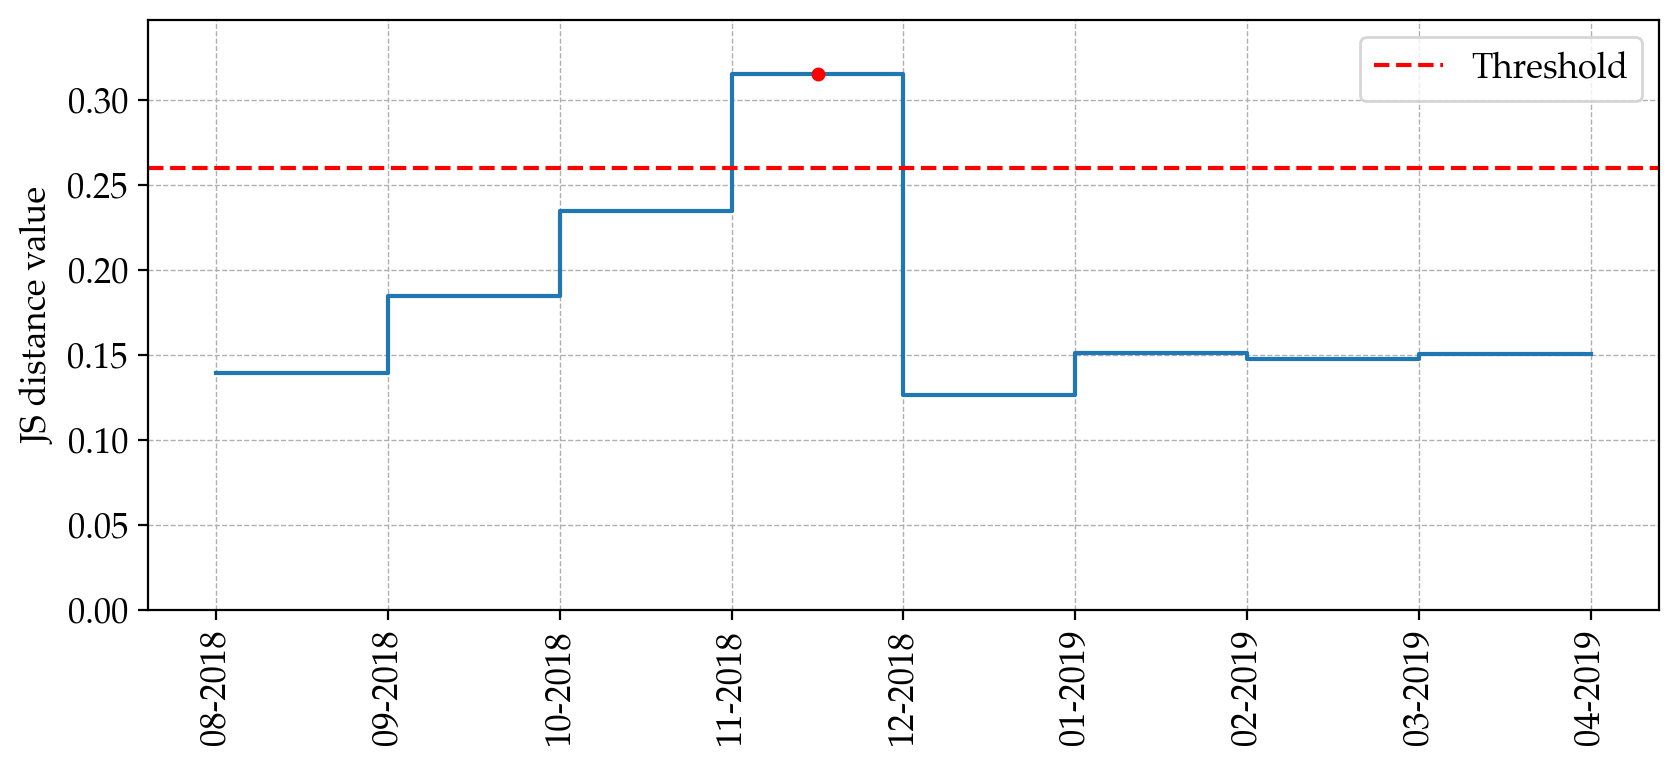

In [11]:
import plot_function_results

from plot_function_results import (drift_plot_v2, styled_step_plot_with_dots, rename_cluster_keys,
                                   compute_relative_popularity, plot_cluster_relative_popularity,
                                   plot_feature_kde_changes, apply_new_names, plot_clusters_delay,
                                   plot_average_load_and_delay_separate)

plot1_params(fsize1_=12.5, dpi1_=200)
global_start_date = "07-2018"
global_end_date = "04-2019"

styled_step_plot_with_dots(js_md_per_month, threshold=0.26)

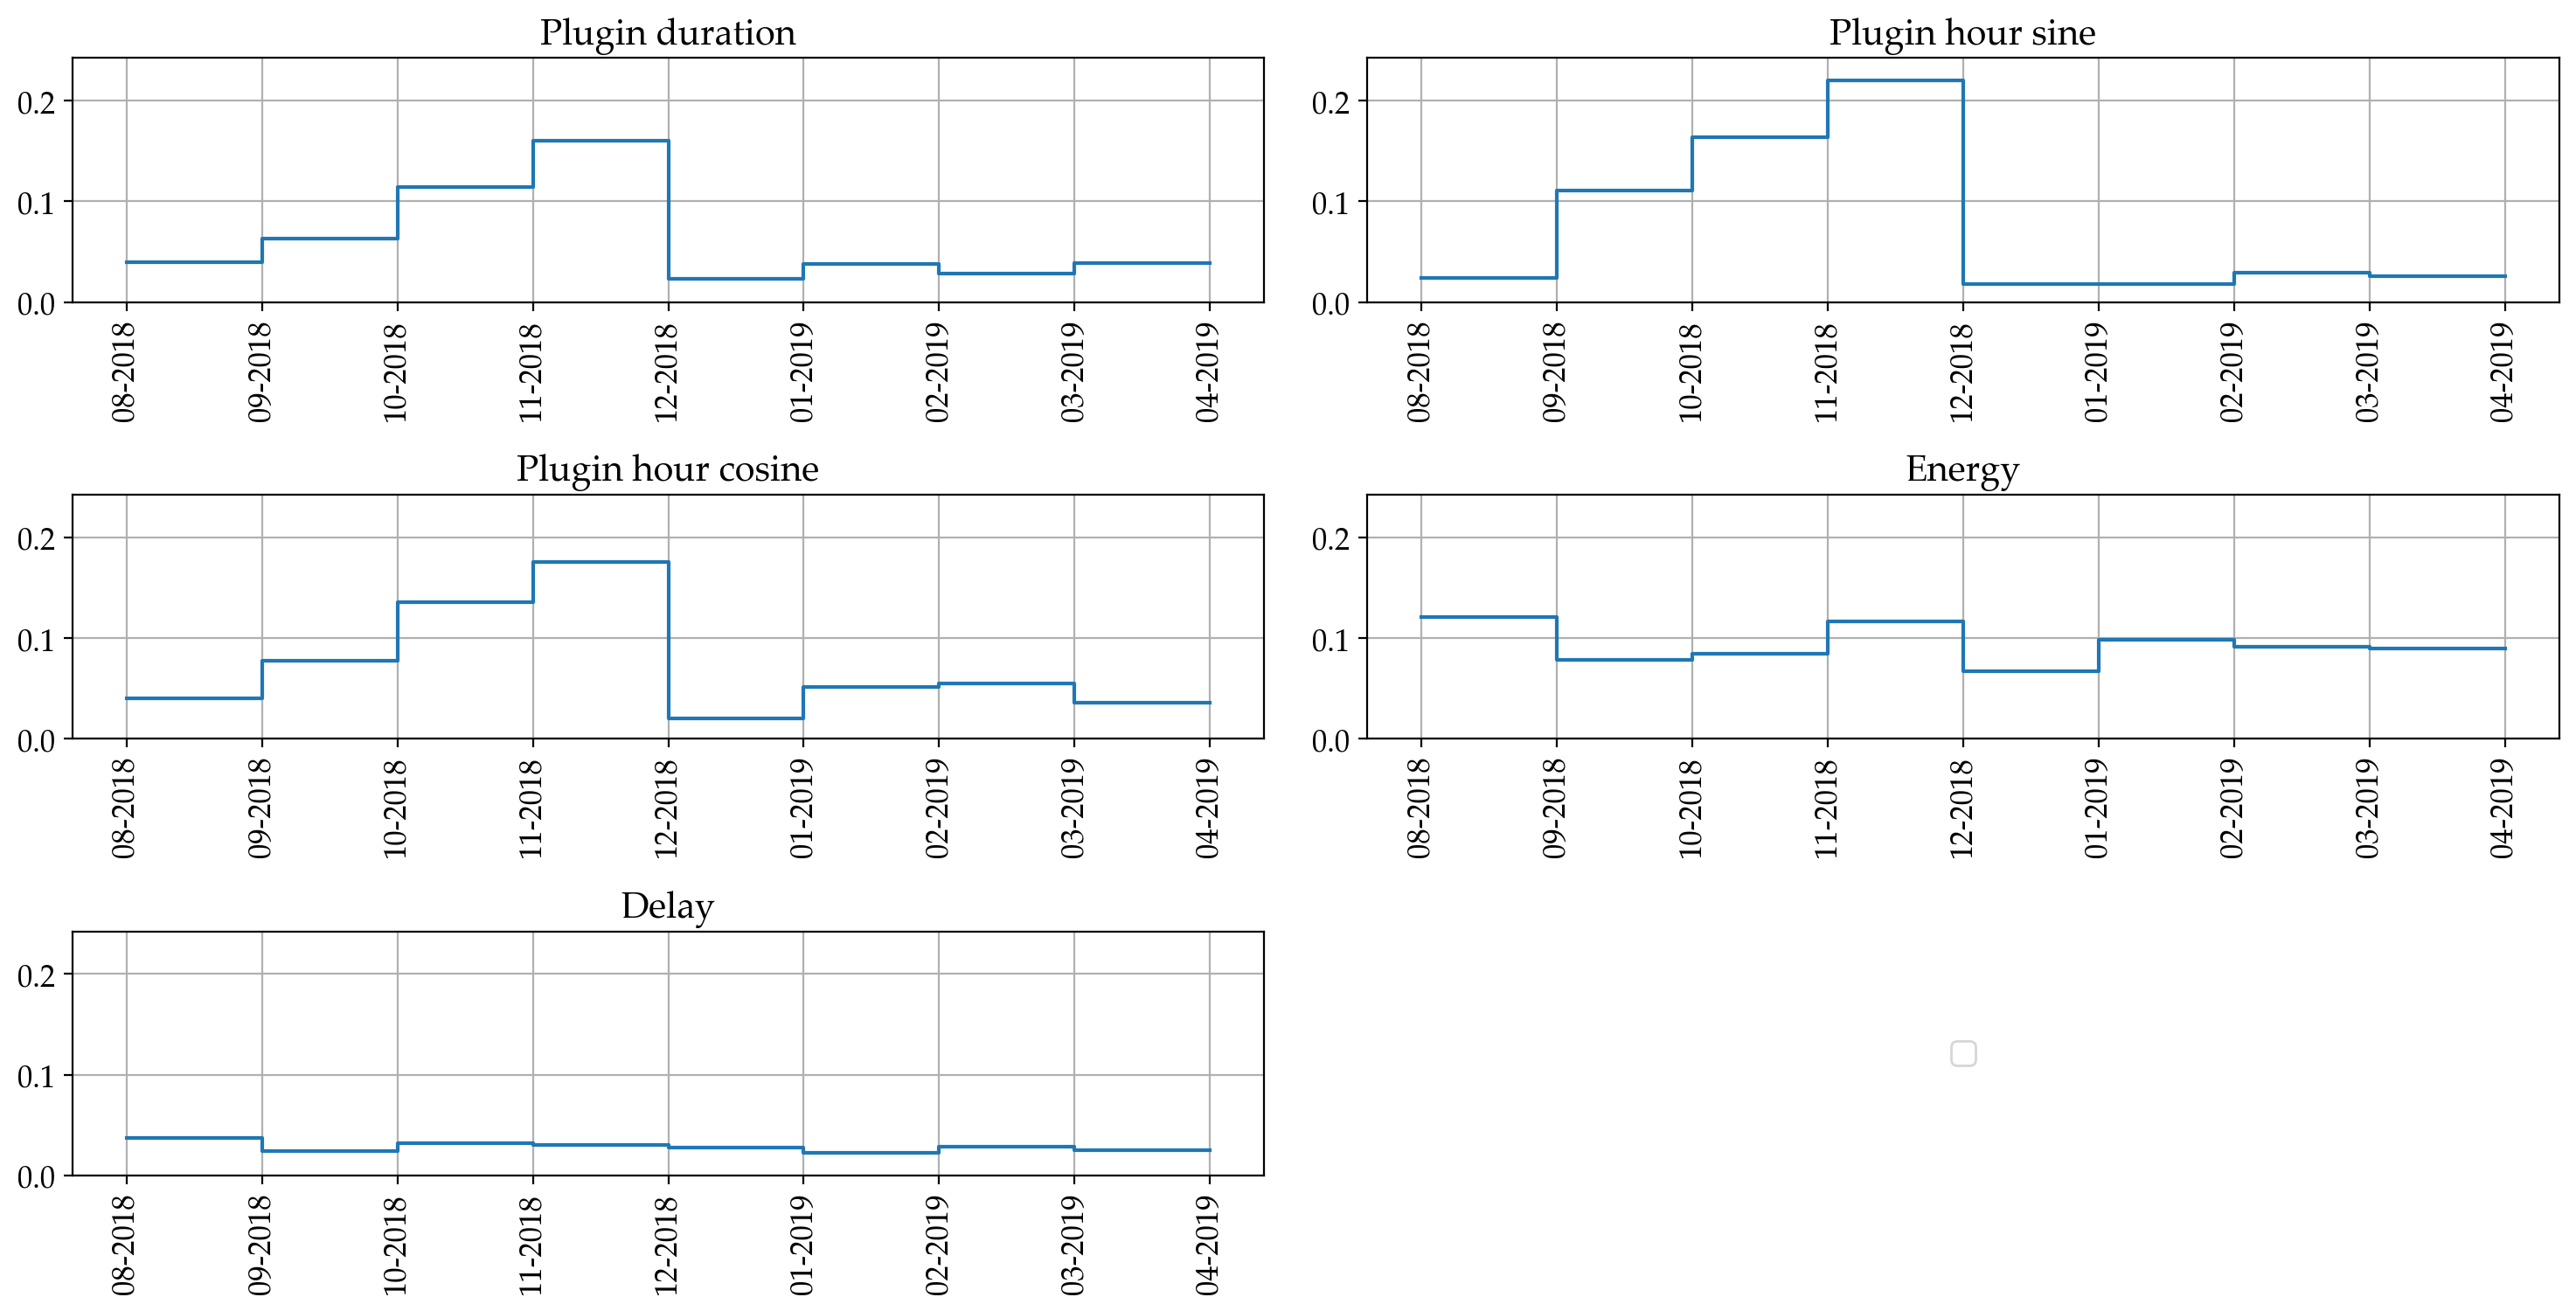

In [12]:
drift_plot_v2(js_per_feature_mat, js_mat_time_order, global_end_date)

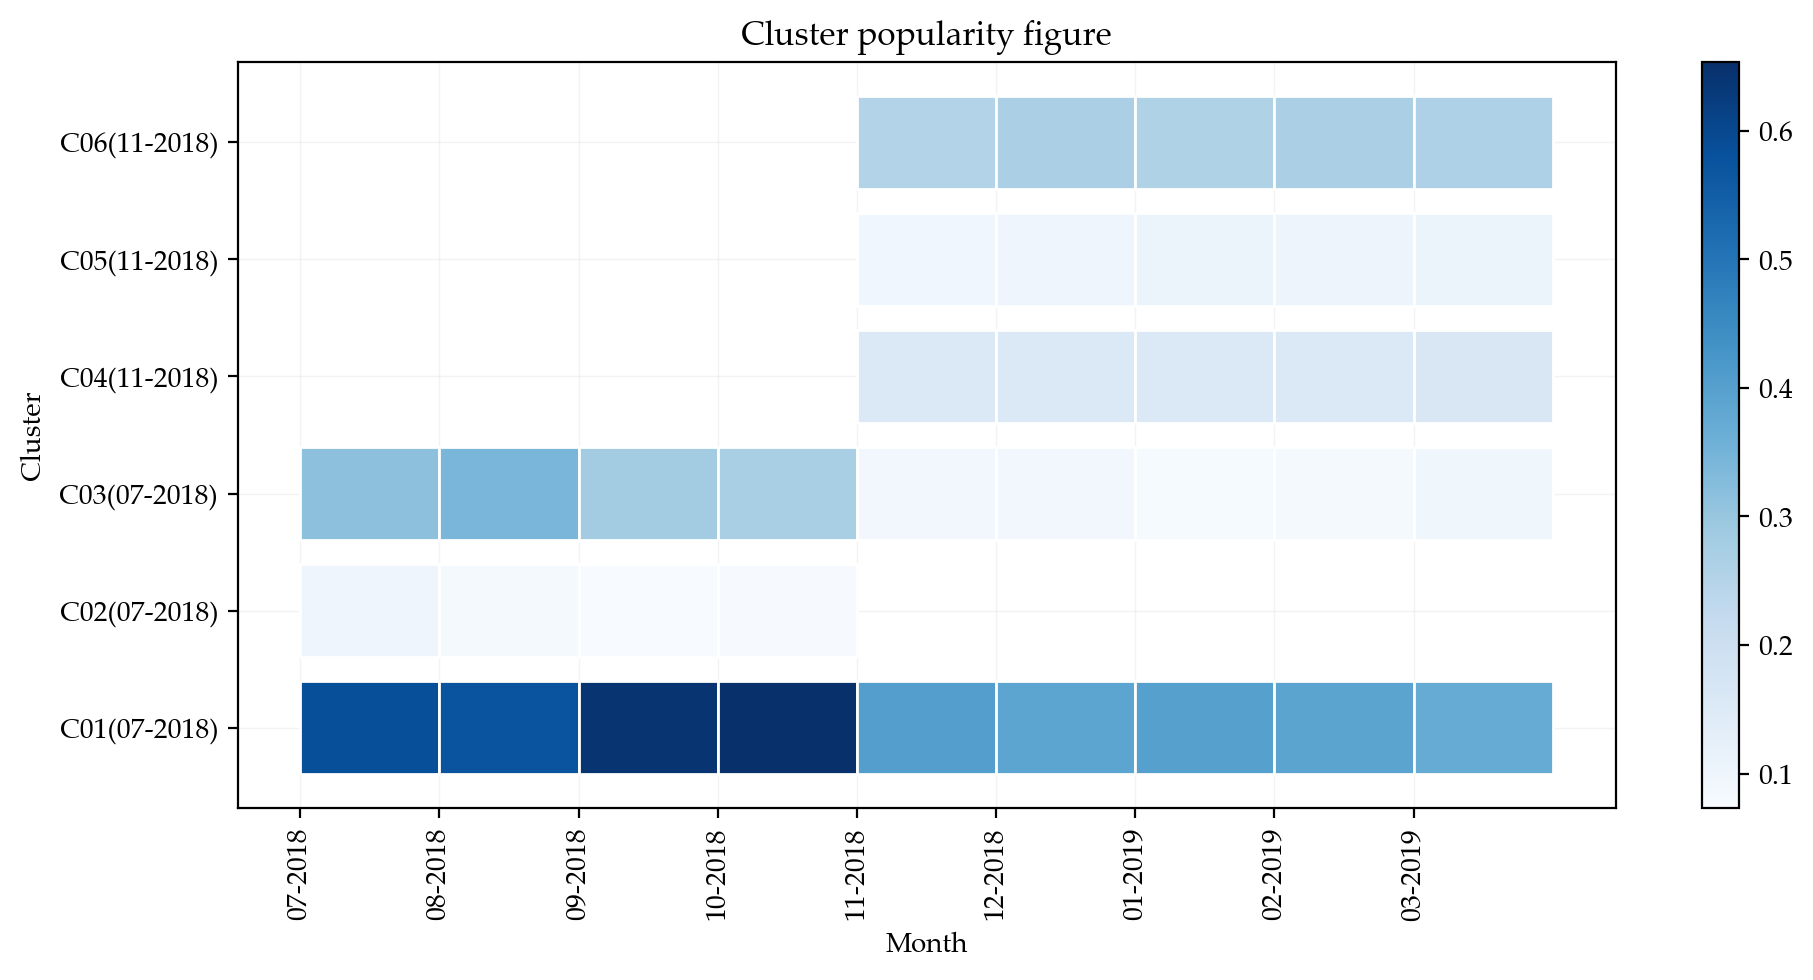

In [20]:
re_ordered_clusters, old_new_tags = rename_cluster_keys(cluster_kdes)
relative_popularity_dict = compute_relative_popularity(re_ordered_clusters)
fig, ax, corrected_data, key_old_new = plot_cluster_relative_popularity(
    relative_popularity_dict
)

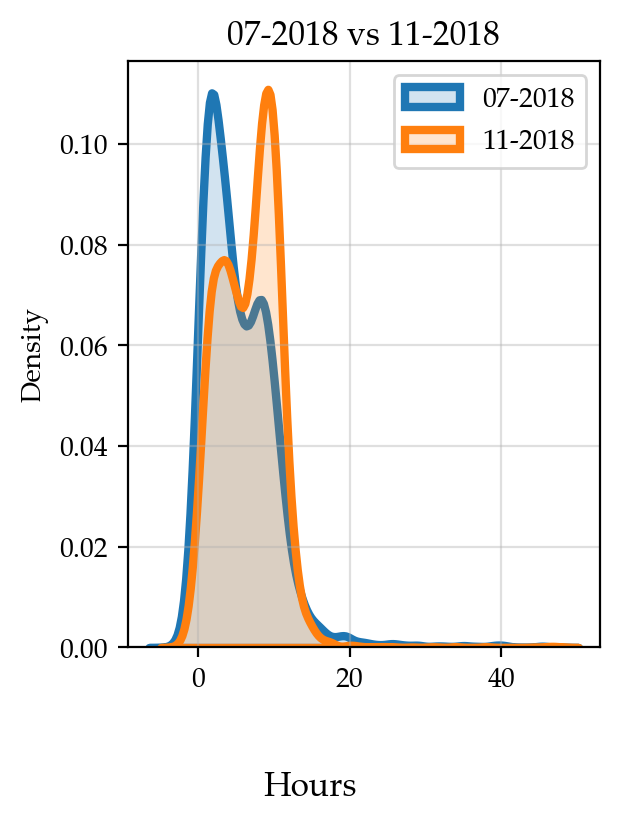

In [21]:
feature_names = ["Plugin duration", 'Plugin hour sine', "Plugin hour cosine", 'Energy', 'Delay']
plot_feature_kde_changes(
    feature_name="Plugin duration",
    feature_names=feature_names,
    js_per_feature_mat=js_per_feature_mat,
    js_mat_time_order=js_mat_time_order,
    all_monthly_kde=all_monthly_kde,
    scaler=state["scaler"],
    months_to_compare=[
        "07-2018",
        "11-2018",

    ],
)

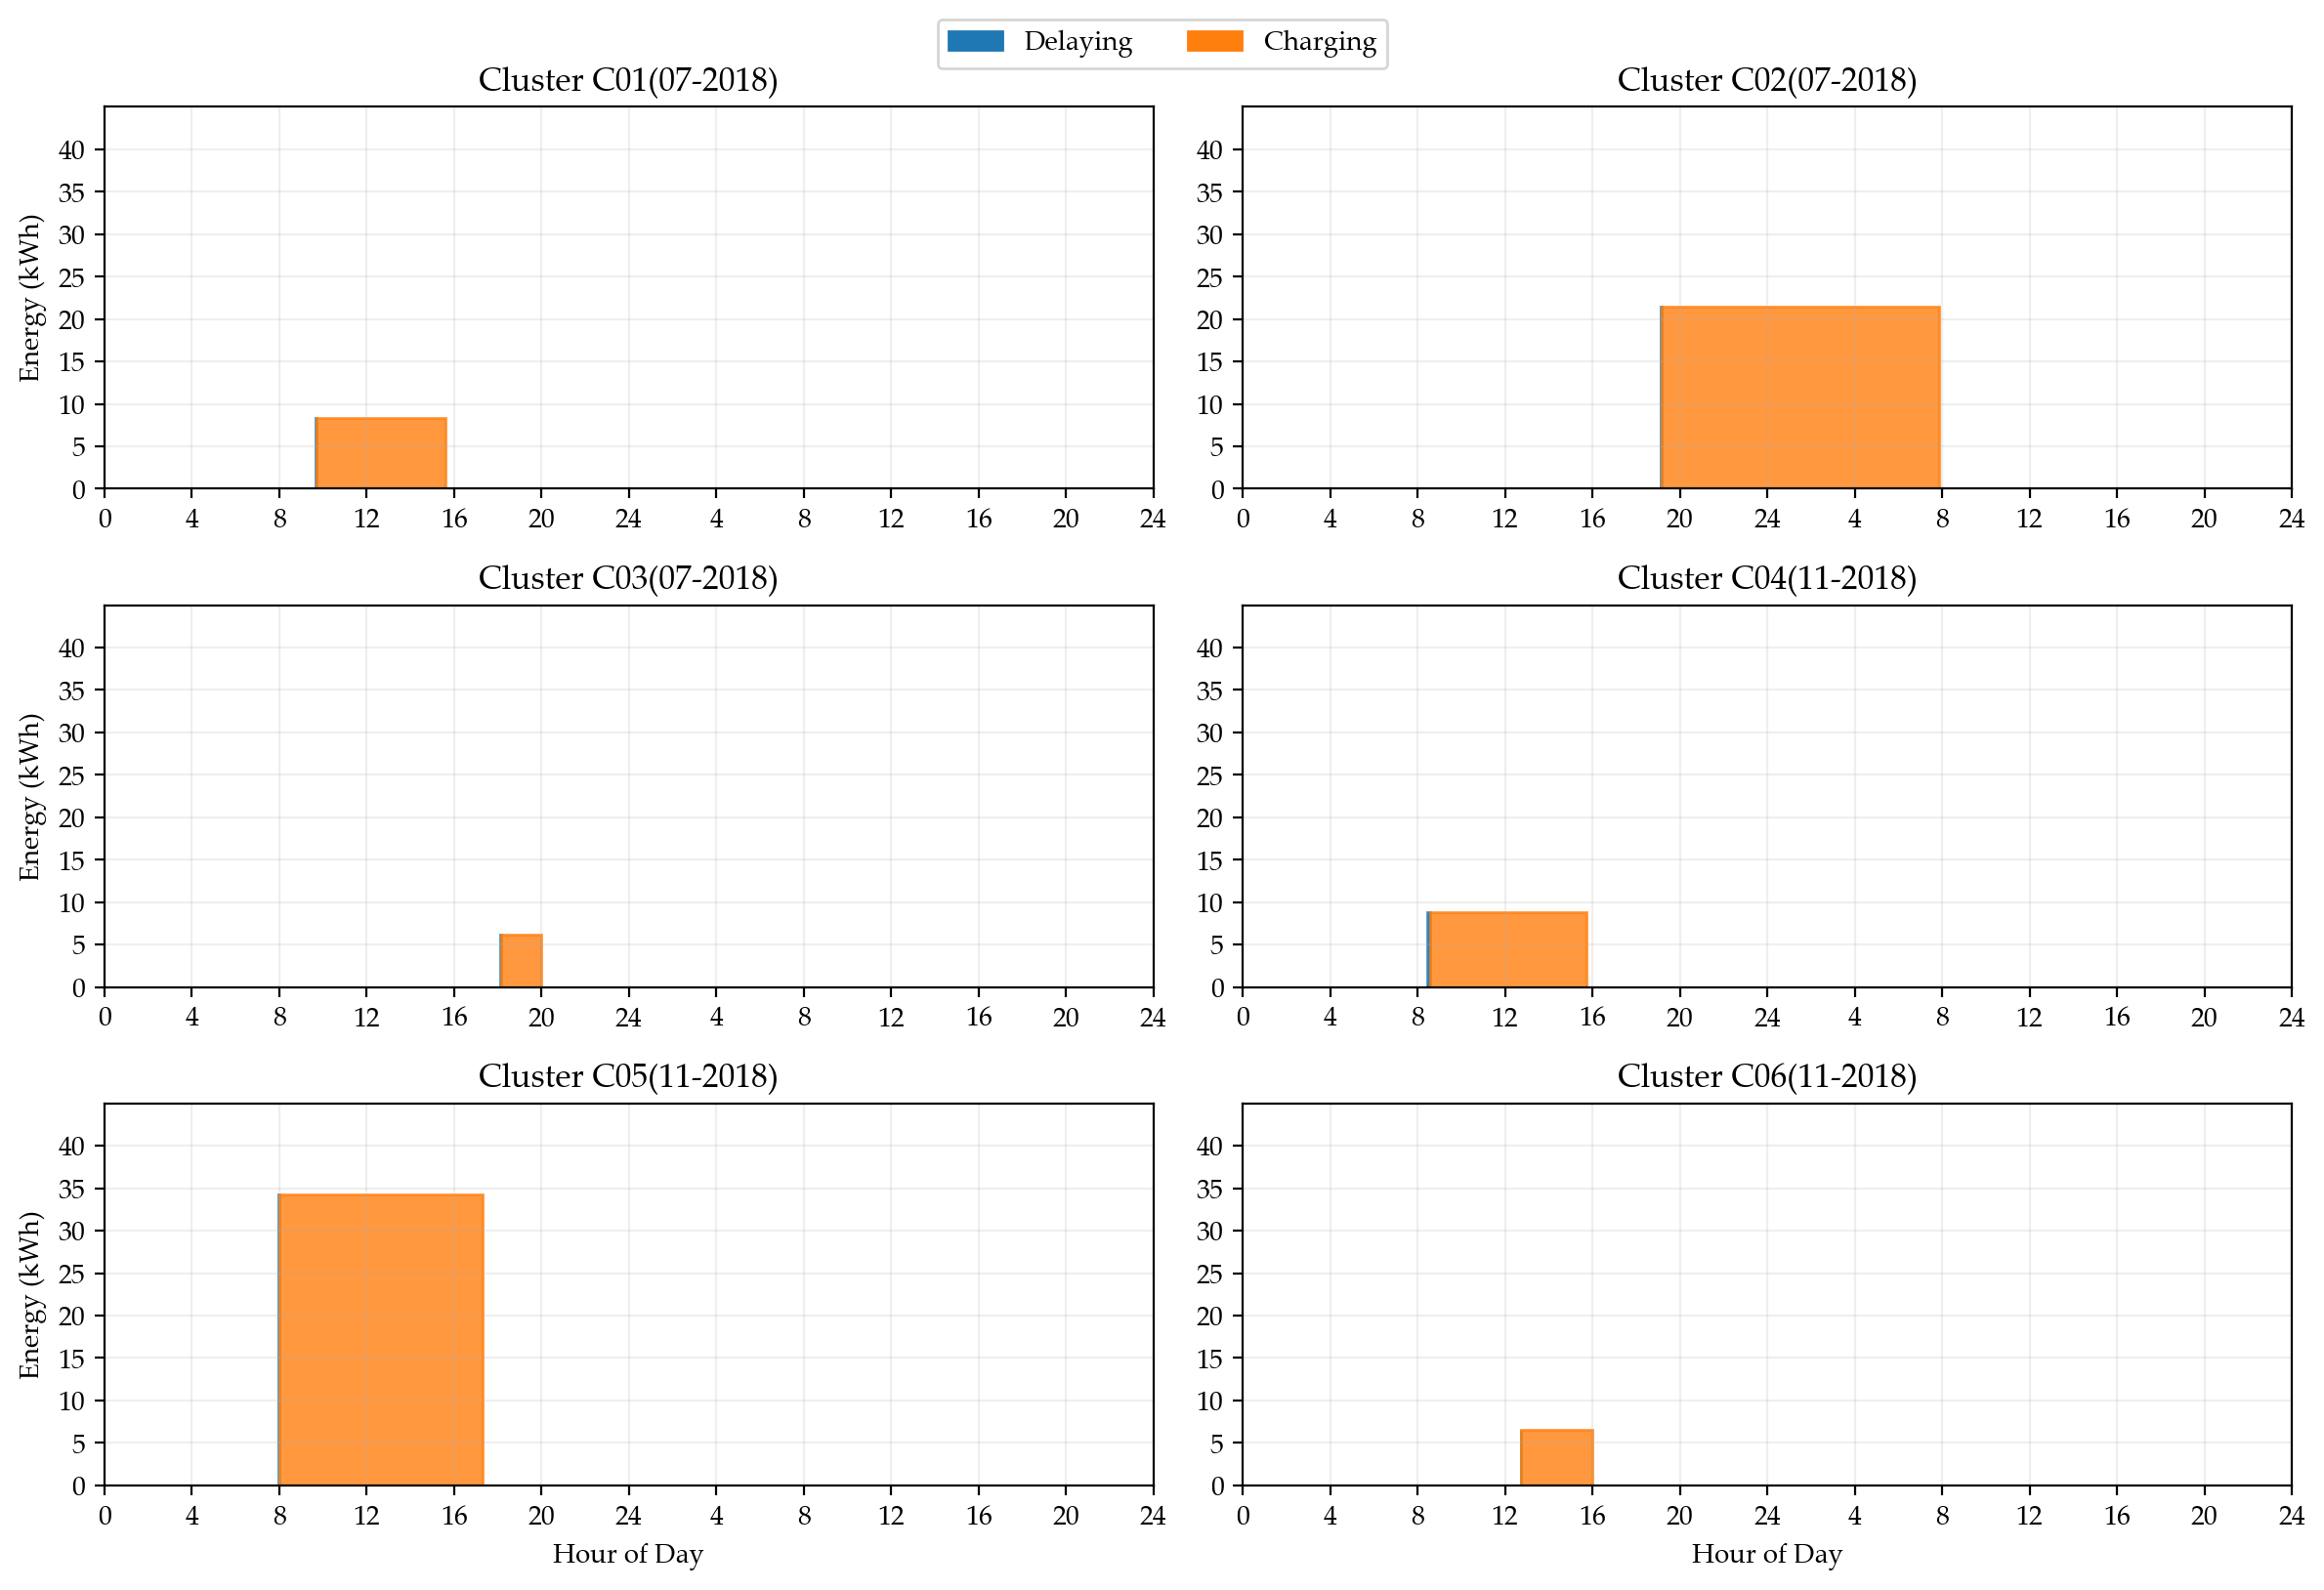

In [22]:
cluster_objects_pool = apply_new_names(cluster_objects_pool, old_new_tags)
cluster_objects_pool = apply_new_names(cluster_objects_pool, key_old_new)
subset_dict = dict(list(cluster_objects_pool.items())[0:8])

features = ['plugin_duration', 'plugin_hour_sine', 'plugin_hour_cosine', 'energy', 'delay']
df_ct = plot_clusters_delay(subset_dict, scaler, features)

In [21]:
import importlib.metadata
import platform


PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
}


def get_version(package_name: str) -> str:
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "Not installed"


print(f"Python: {platform.python_version()}")
print()

print("| Package | Version |")
print("|---|---|")

for import_name, package_name in PACKAGES.items():
    version = get_version(package_name)
    print(f"| {package_name} | {version} |")

Python: 3.11.9

| Package | Version |
|---|---|
| numpy | 2.1.3 |
| pandas | 2.3.1 |
| matplotlib | 3.10.8 |
| seaborn | 0.13.2 |
| scikit-learn | 1.7.1 |
| scipy | 1.16.1 |


In [ ]:
cluster_names = [
     'C01(07-2018)',

]

cluster_weights = {
     'C01(07-2018)': 1,

}
load_profile, delay_profile, df_joint = plot_average_load_and_delay_separate(
    kdes=cluster_objects_pool,
    cluster_names=cluster_names,
    scaler=state["scaler"],
    cluster_weights=cluster_weights,
    n_samples_per_cluster=5000,
    random_state=42,
    kwh_per_hour=11,

)